In [ ]:
import pandas as pd

file_path = '/content/structured_endometriosis_data.csv'

df = pd.read_csv(file_path)
display(df.head())

,Age,Menstrual_Irregularity,Chronic_Pain_Level,Hormone_Level_Abnormality,Infertility,BMI,Diagnosis
0,24,1,8.361531,0,0,19.451314,0
1,37,1,4.995508,0,0,22.388436,0
2,46,1,3.363996,1,0,21.320443,0
3,32,1,5.246037,0,0,20.177715,1
4,28,1,3.898932,1,0,23.538103,1


In [ ]:
df_variance = df.var()
display(df_variance)

,0
Age,84.737694
Menstrual_Irregularity,0.211015
Chronic_Pain_Level,3.936079
Hormone_Level_Abnormality,0.241725
Infertility,0.209338
BMI,15.144663
Diagnosis,0.241542


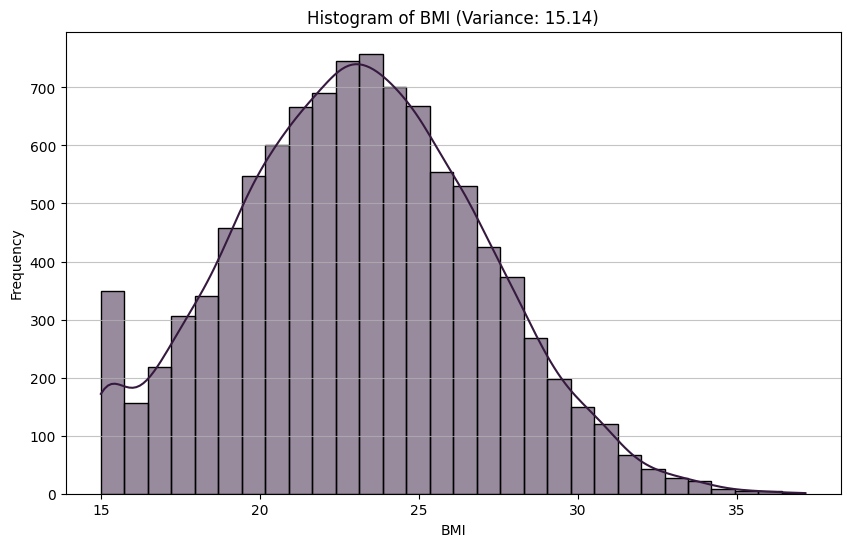

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

bmi_variance = df_variance['BMI']

plt.figure(figsize=(10, 6))
sns.histplot(df['BMI'], kde=True, bins=30, color=sns.color_palette("rocket")[0])
plt.title(f'Histogram of BMI (Variance: {bmi_variance:.2f})')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

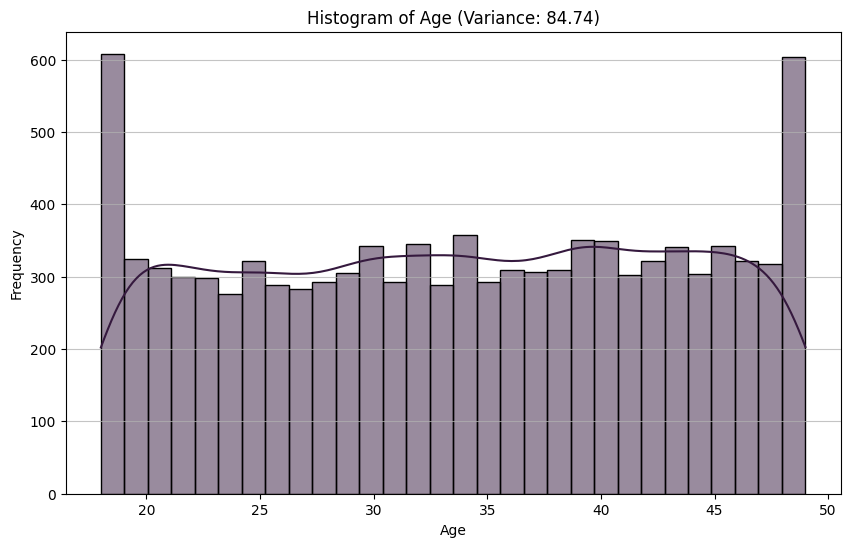

In [ ]:
age_variance = df_variance['Age']

plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], kde=True, bins=30, color=sns.color_palette("rocket")[0])
plt.title(f'Histogram of Age (Variance: {age_variance:.2f})')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

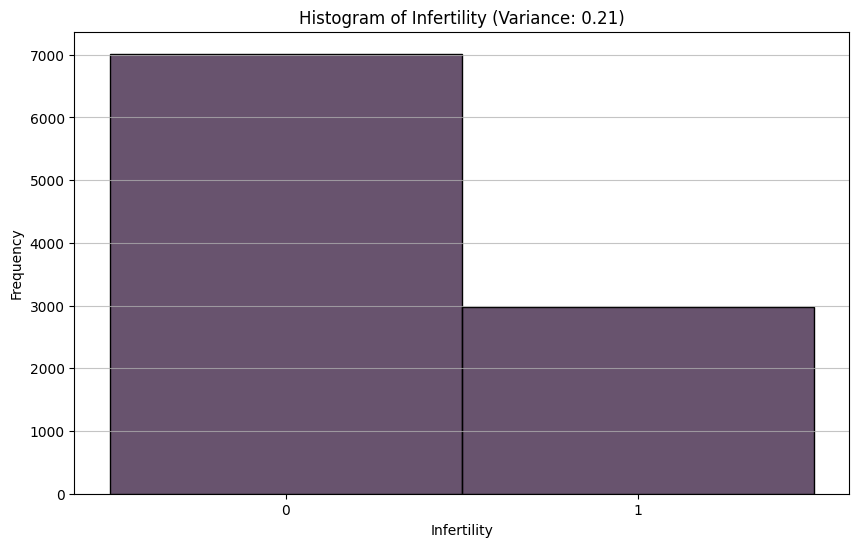

In [ ]:
infertility_variance = df_variance['Infertility']

plt.figure(figsize=(10, 6))
sns.histplot(df['Infertility'], kde=False, bins=[-0.5, 0.5, 1.5], discrete=True, color=sns.color_palette("rocket")[0])
plt.xticks([0, 1])
plt.title(f'Histogram of Infertility (Variance: {infertility_variance:.2f})')
plt.xlabel('Infertility')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

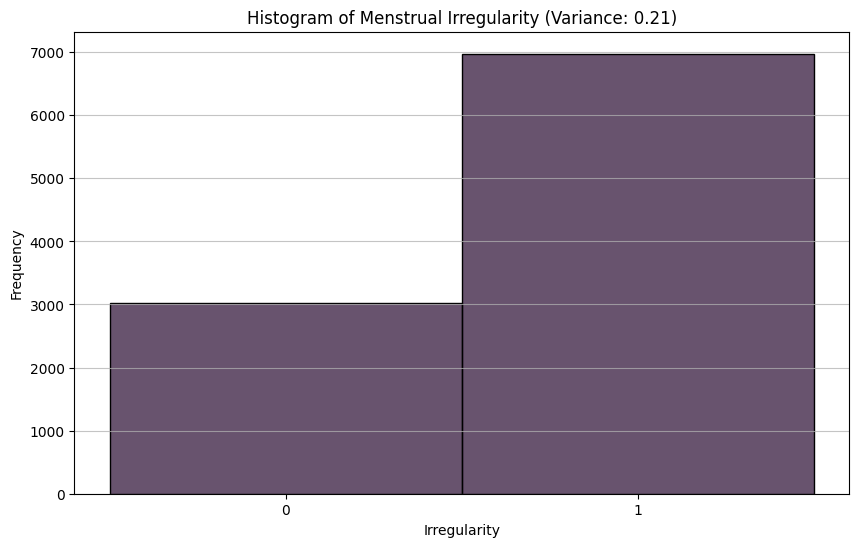

In [ ]:
irregularity_variance = df_variance['Menstrual_Irregularity']

plt.figure(figsize=(10, 6))
sns.histplot(df['Menstrual_Irregularity'], kde=False, bins=[-0.5, 0.5, 1.5], discrete=True, color=sns.color_palette("rocket")[0])
plt.xticks([0, 1])
plt.title(f'Histogram of Menstrual Irregularity (Variance: {irregularity_variance:.2f})')
plt.xlabel('Irregularity')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns for scaling
numerical_cols = ['Age', 'Chronic_Pain_Level', 'BMI']

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply StandardScaler to the numerical columns
df_scaled = df.copy() # Create a copy to avoid modifying the original DataFrame directly
df_scaled[numerical_cols] = scaler.fit_transform(df_scaled[numerical_cols])

#print("Original numerical columns (first 5 rows):")
#display(df[numerical_cols].head())

#print("\nScaled numerical columns (first 5 rows):")
#display(df_scaled[numerical_cols].head())
df_variance = df.var()
display(df_variance)

df_scaled_variance = df_scaled.var()
display(df_scaled_variance)

,0
Age,84.737694
Menstrual_Irregularity,0.211015
Chronic_Pain_Level,3.936079
Hormone_Level_Abnormality,0.241725
Infertility,0.209338
BMI,15.144663
Diagnosis,0.241542


,0
Age,1.000100
Menstrual_Irregularity,0.211015
Chronic_Pain_Level,1.000100
Hormone_Level_Abnormality,0.241725
Infertility,0.209338
BMI,1.000100
Diagnosis,0.241542


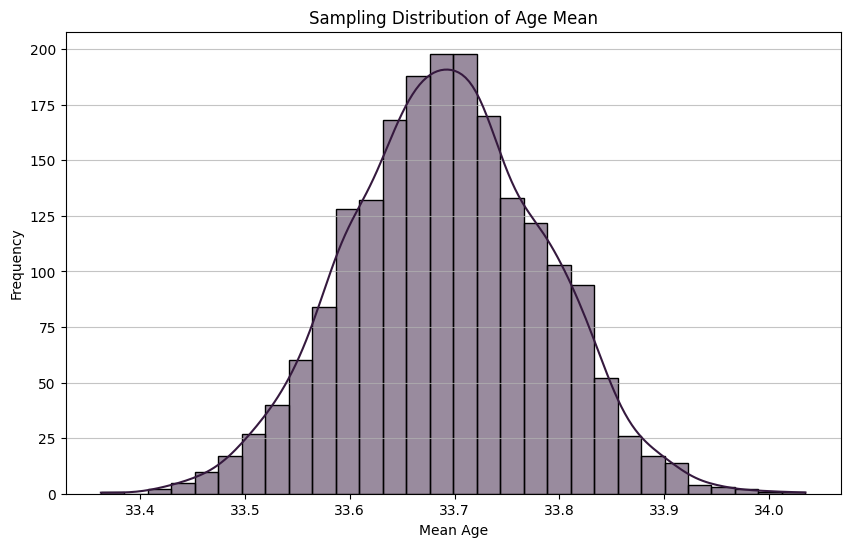

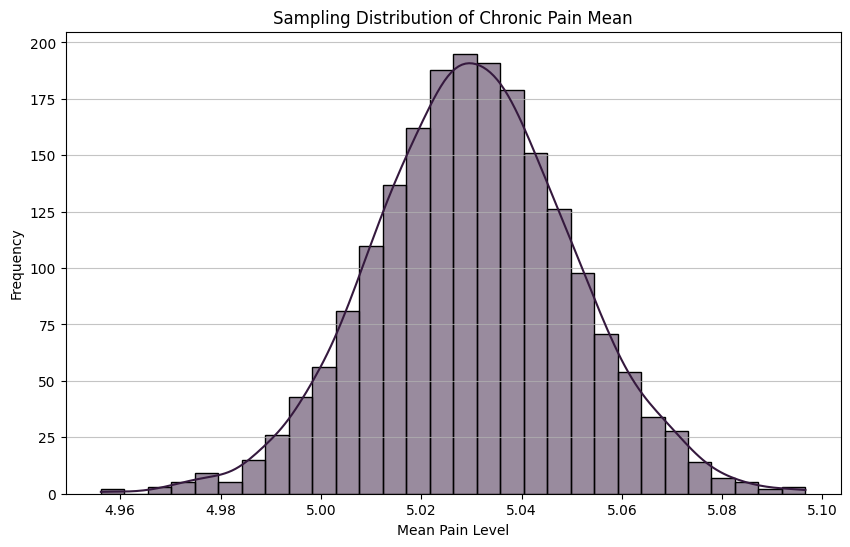

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def bootstrap_means(series, n_boot=2000):
    means = []
    values = series.values

    for _ in range(n_boot):
        sample = np.random.choice(values, size=len(values), replace=True)
        means.append(sample.mean())

    return means

# Sampling distributions
age_sampling = bootstrap_means(df["Age"])
pain_sampling = bootstrap_means(df["Chronic_Pain_Level"])

# Plot Age
plt.figure(figsize=(10, 6))
sns.histplot(age_sampling, bins=30, kde=True, color=sns.color_palette("rocket")[0])
plt.title("Sampling Distribution of Age Mean")
plt.xlabel("Mean Age")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.75)
plt.show()

# Plot Pain
plt.figure(figsize=(10, 6))
sns.histplot(pain_sampling, bins=30, kde=True, color=sns.color_palette("rocket")[0])
plt.title("Sampling Distribution of Chronic Pain Mean")
plt.xlabel("Mean Pain Level")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
df["Chronic_Pain_Level"] = df["Chronic_Pain_Level"].round(1)

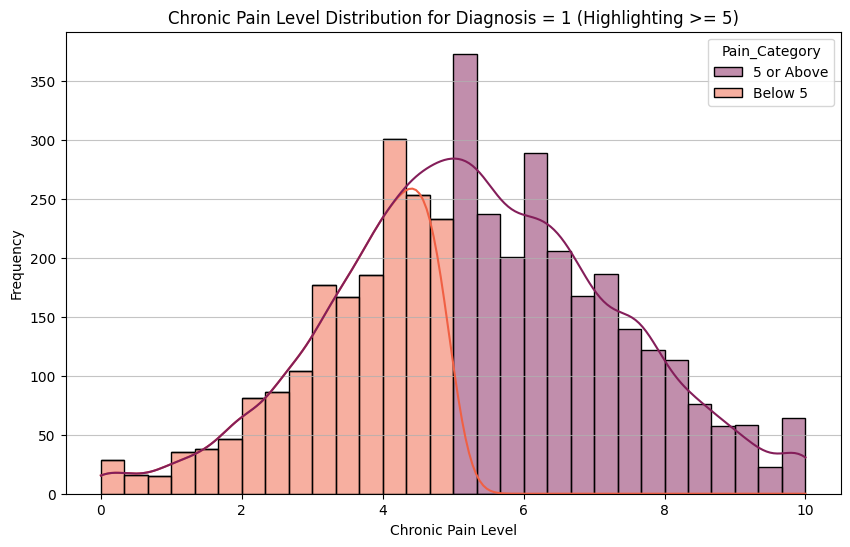

Number of individuals with Chronic_Pain_Level >= 5 (Diagnosis = 1): 2313


In [ ]:
import numpy as np

plt.figure(figsize=(10, 6))

df_diagnosis_1 = df[df['Diagnosis'] == 1].copy()

# Create a categorical column for pain level for coloring
df_diagnosis_1['Pain_Category'] = np.where(df_diagnosis_1['Chronic_Pain_Level'] >= 5, '5 or Above', 'Below 5')

sns.histplot(data=df_diagnosis_1, x='Chronic_Pain_Level', hue='Pain_Category', bins=30, kde=True, palette='rocket', multiple='stack')

plt.title('Chronic Pain Level Distribution for Diagnosis = 1 (Highlighting >= 5)')
plt.xlabel('Chronic Pain Level')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

pain_above_5_count = df_diagnosis_1[df_diagnosis_1['Chronic_Pain_Level'] >= 5].shape[0]
print(f"Number of individuals with Chronic_Pain_Level >= 5 (Diagnosis = 1): {pain_above_5_count}")

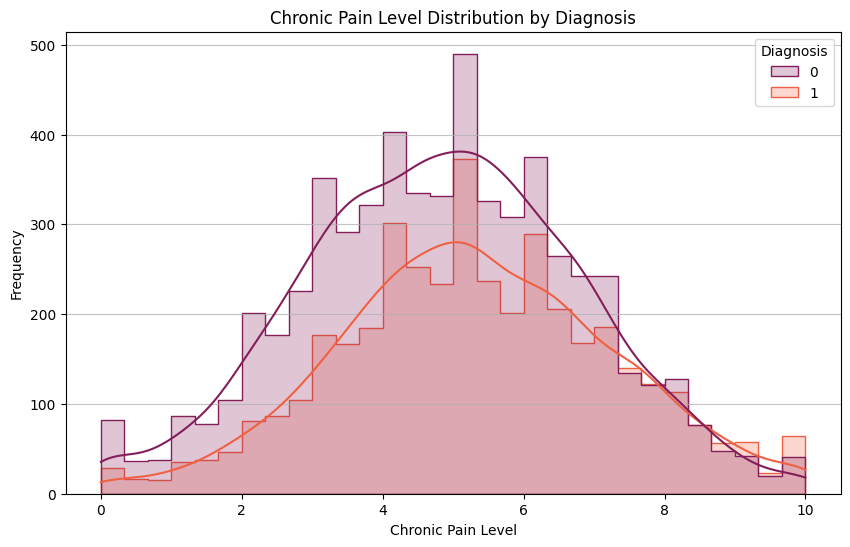

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="Chronic_Pain_Level",
    hue="Diagnosis",
    bins=30,
    kde=True,
    palette="rocket",
    element="step"
)

plt.title("Chronic Pain Level Distribution by Diagnosis")
plt.xlabel("Chronic Pain Level")
plt.ylabel("Frequency")

plt.grid(axis='y', alpha=0.75)
plt.show()

<Axes: xlabel='Chronic_Pain_Level', ylabel='Density'>

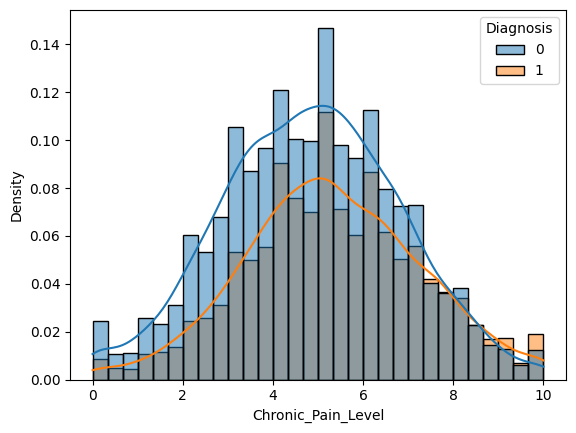

In [ ]:
sns.histplot(
    data=df,
    x="Chronic_Pain_Level",
    hue="Diagnosis",
    bins=30,
    kde=True,
    stat="density"
)

In [ ]:
top_5_ages_diagnosis_1 = df[df['Diagnosis'] == 1]['Age'].value_counts().nlargest(5)
print("Top 5 edades con diagnóstico de Endometriosis (Diagnosis = 1):")
display(top_5_ages_diagnosis_1)

Top 5 edades con diagnóstico de Endometriosis (Diagnosis = 1):


,count
Age,
40,155
39,154
43,147
46,145
34,145


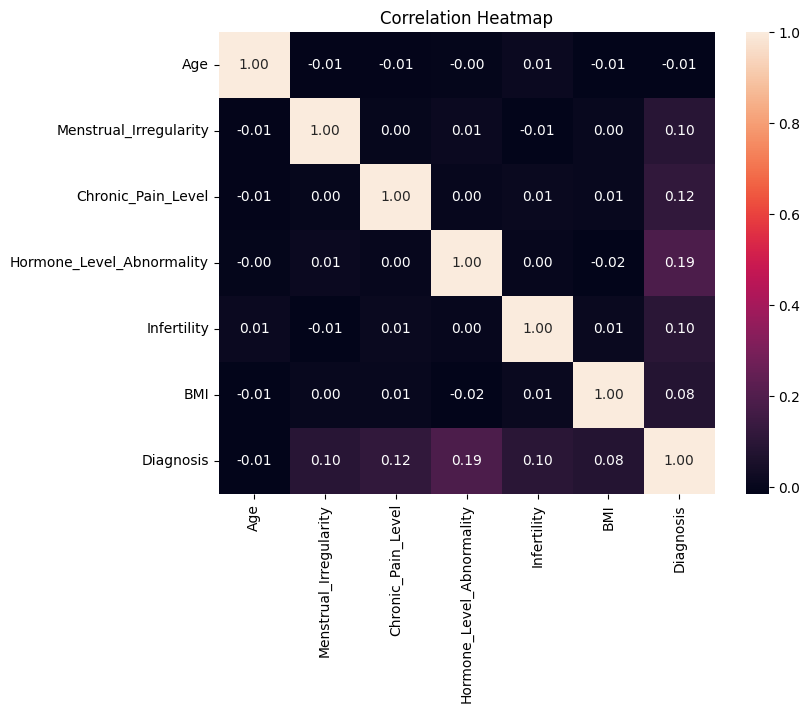

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="rocket", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

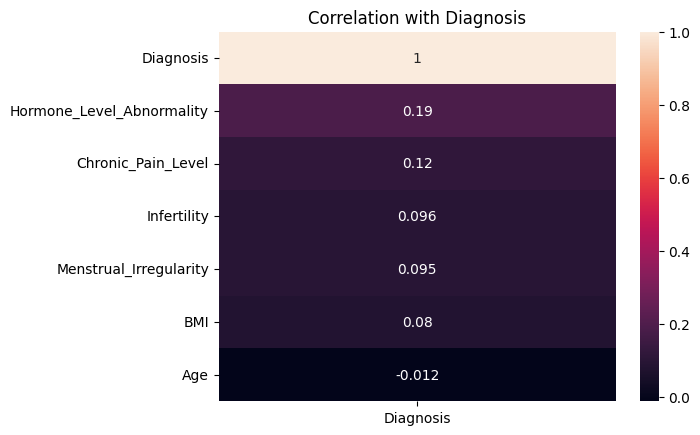

In [ ]:
corr_target = df.corr()[["Diagnosis"]].sort_values(by="Diagnosis", ascending=False)

sns.heatmap(corr_target, annot=True, cmap="rocket")
plt.title("Correlation with Diagnosis")
plt.show()

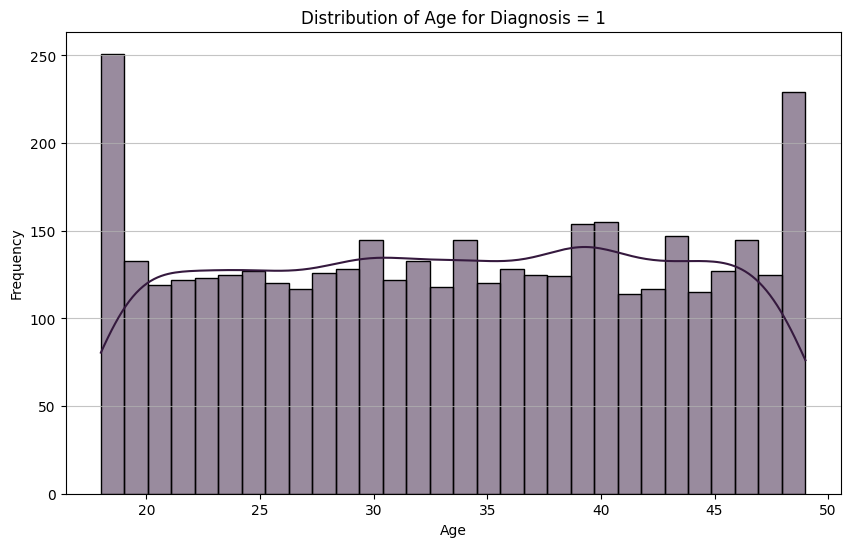

Edad promedio de diagnóstico para Diagnosis = 1: 33.56 años


In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df[df['Diagnosis'] == 1], x='Age', kde=True, bins=30, color=sns.color_palette("rocket")[0])
plt.title('Distribution of Age for Diagnosis = 1')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

average_age_diagnosis_1 = df[df['Diagnosis'] == 1]['Age'].mean()
print(f"Edad promedio de diagnóstico para Diagnosis = 1: {average_age_diagnosis_1:.2f} años")

# ACTIVIDA EN CLASE


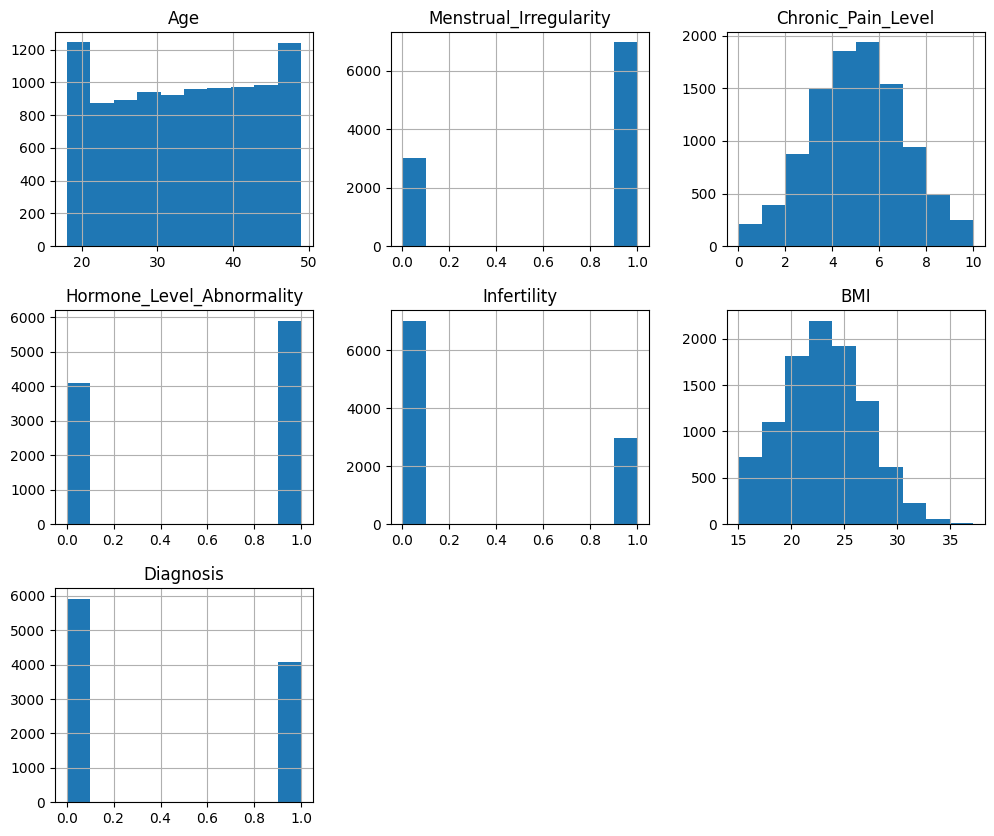

In [ ]:
#Obtener los histogramas de cada una de las variables
import matplotlib.pyplot as plt
import seaborn as sns


df.hist(figsize=(12, 10))
plt.show()

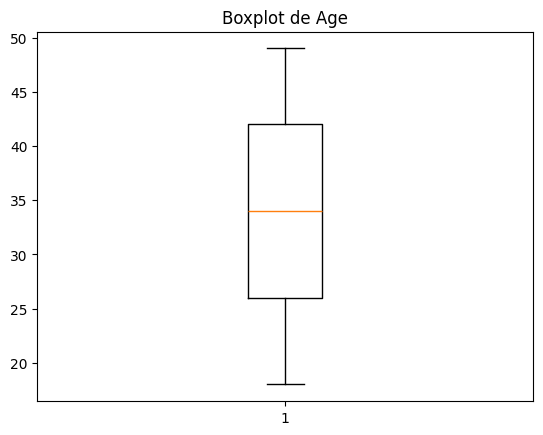

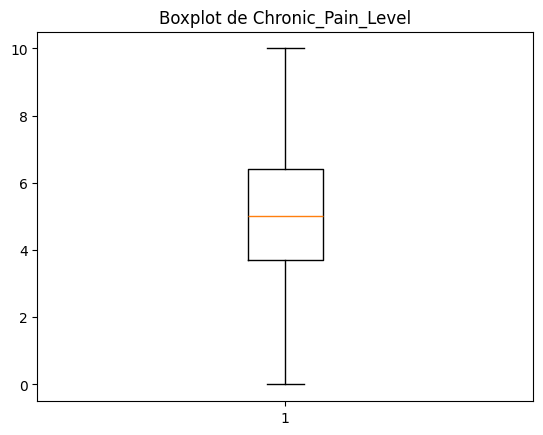

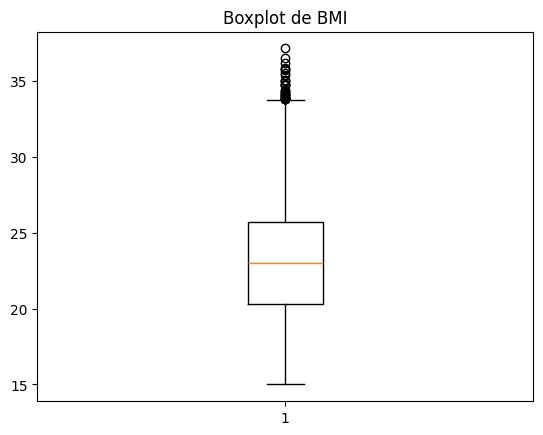

In [ ]:
for col in numerical_cols:
    plt.figure()
    plt.boxplot(df[col].dropna())
    plt.title(f'Boxplot de {col}')
    plt.show()

In [ ]:
outliers_iqr = {}

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outliers_iqr[col] = len(outliers)

print(outliers_iqr)

{'Age': 0, 'Chronic_Pain_Level': 0, 'BMI': 30}
